# Tarea Análisis Exploratorio de Datos

**Autor:** Gil Brandon Garcia Contreras
**Fecha:** 16 de febrero de 2026

## Objetivo

Esta tarea busca que experimenten directamente con el proceso de análisis exploratorio de datos (EDA). A diferencia de otros temas del curso donde aprenderán algoritmos específicos con pasos definidos, el EDA es fundamentalmente una actividad artesanal y creativa. No existe una receta única: cada dataset cuenta una historia diferente, y su trabajo es descubrir cuál es esa historia mediante preguntas inteligentes y visualizaciones apropiadas.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 

# Cargar datos
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [11]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1 # Creación de variable de tamaño de familia
titanic.head() # Primeras filas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [13]:
titanic.describe() #Describe los datos

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [14]:
titanic.info() #Muestra los tipos de variables y la cantidad de valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


## Parte 1: Variación (¿Cómo varían mis datos?)

Preguntas a analizar:

- Survived: ¿Cuanto porcentaje de gente sobrevivio?
- Pclass: ¿Cuánta gente había de cada clase?
- Fare: ¿Como se distribuyen la tarifa?
- Age: ¿Como se distribuye la edad?
- FamilySize: ¿Cuanta gente viajaba en familia?

In [138]:
survived = titanic['Survived'].value_counts()

print(survived, (survived / len(titanic) * 100).round(2))

Survived
0    549
1    342
Name: count, dtype: int64 Survived
0    61.62
1    38.38
Name: count, dtype: float64


In [137]:
pcclass = titanic['Pclass'].value_counts()

print(pcclass, (pcclass / len(titanic) * 100).round(2))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64 Pclass
3    55.11
1    24.24
2    20.65
Name: count, dtype: float64


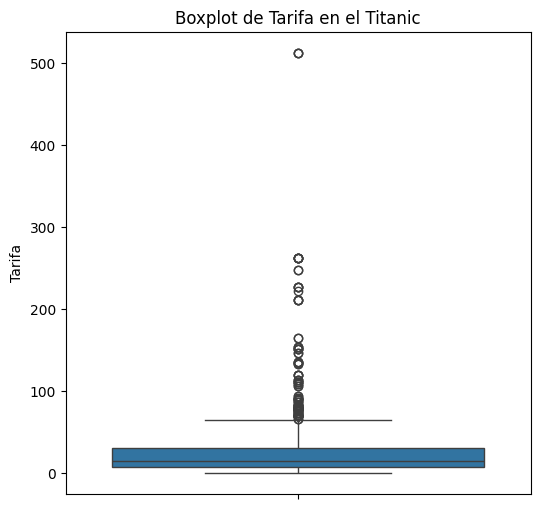

     PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292          NaN        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

     FamilySize  
258           1  
679           2  
737           1  


In [83]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=titanic, y='Fare')
plt.ylabel('Tarifa')
plt.title('Boxplot de Tarifa en el Titanic')
plt.show()

mayores_300 = titanic.query('Fare > 300')

print(mayores_300)

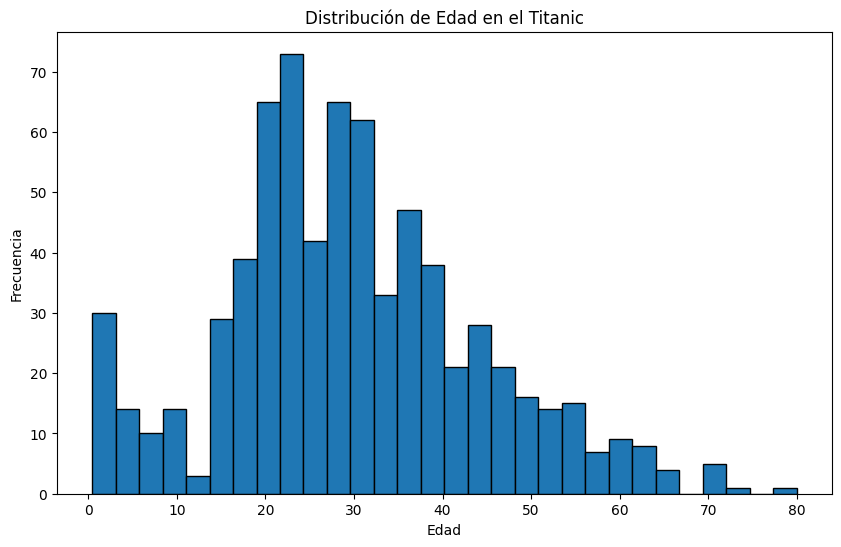

22 2.4691358024691357
113 12.682379349046016


In [174]:
plt.figure(figsize=(10, 6))
plt.hist(titanic['Age'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad en el Titanic')
plt.show()
mayores_60 = titanic.query('Age > 60')
menores_18 = titanic.query('Age < 18')

print(len(mayores_60), len(mayores_60) / len(titanic) * 100)
print(len(menores_18), len(menores_18) / len(titanic) * 100)

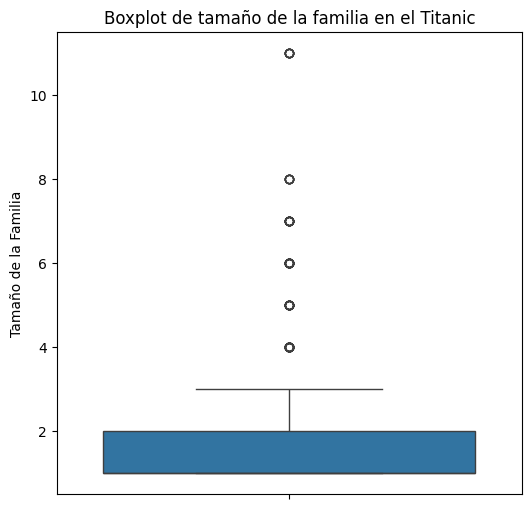

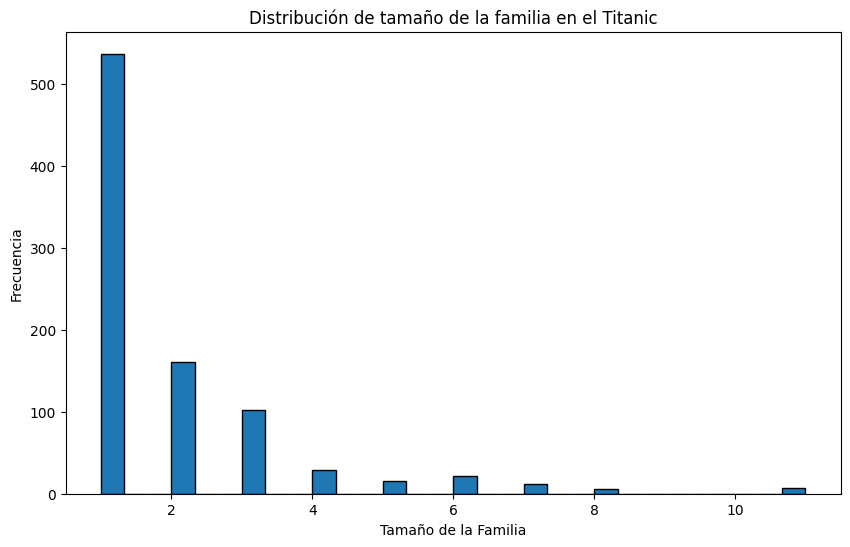

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64 FamilySize
1     60.27
2     18.07
3     11.45
4      3.25
6      2.47
5      1.68
7      1.35
11     0.79
8      0.67
Name: count, dtype: float64      PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas Henry    male   
180          181         0       3       Sage, Miss. Constance Gladys  female   
201          202         0       3                Sage, Mr. Frederick    male   
324          325         0       3           Sage, Mr. George John Jr    male   
792          793         0       3            Sage, Miss. Stella Anna  female   
846          847         0       3           Sage, Mr. Douglas Bullen    male   
863          864         0       3  Sage, Miss. Dorothy Edith "Dolly"  female   

     Age  SibSp  Parch    Ticket   Fare Cabin Embarked  FamilySize  
159  NaN

In [134]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=titanic, y='FamilySize')
plt.ylabel('Tamaño de la Familia')
plt.title('Boxplot de tamaño de la familia en el Titanic')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(titanic['FamilySize'].dropna(), bins=30, edgecolor='black')
plt.xlabel('Tamaño de la Familia')
plt.ylabel('Frecuencia')
plt.title('Distribución de tamaño de la familia en el Titanic')
plt.show()

family = titanic['FamilySize'].value_counts()
family_11 = titanic.query('FamilySize >= 11')

print(family, (family / len(titanic) * 100).round(2), family_11)

Tras analizar las 5 variables que me parecían más interesantes, encontré varios detalles curiosos. El porcentaje de sobrevivencia fue del 38 %, el cual me parece alto para la tragedia que fue en su momento. Uno pensaría que la supervivencia estaría por los suelos, aunque, comparándola con los números actuales de supervivencia a catástrofes, claramente se puede ver la diferencia de tecnología entre ambas épocas. 

Por otra parte, analizando las clases de pasajeros, me pareció curioso que la suma porcentual de la segunda y primera clase fuera menor que la enteridad de la tercera. También me sorprendió el hecho de que hubiera más participantes de primera clase que de segunda, algo que denota el fenómeno social que fue el barco en su momento. 

En el apartado de tarifa de boletos se puede notar que existe un punto bastante alejado del resto, alrededor de los 500 dólares. Revisando por todas las personas que pagaron más de 300 dólares, podemos ver que únicamente se encuentran 3 en esta categoría. Haciendo una investigación más profunda, podemos ver que el pasajero principal fue Thomas Drake Martínez Cardeza, el cual llevaba a su madre y un sirviente personal. Él era el único que utilizó una de las dos suites principales dentro del Titanic y la razón principal por la que la media de la tarifa es tan alta. Cabe recalcar que los 3 sobrevivieron. 

Siguiendo con la edad, podemos ver que la mayoría de los pasajeros estaban en un rango de entre 20 y 40 años. Unicamente 26 mayores y 113 menores de edad abordaban el barco, un 2.46 % y 12.7 % respectivamente.

Finalmente, la última variable que analicé fue el tamaño de las familias, una variable creada por mí. En esta se puede observar cómo la mayoría de las personas viajaban sin familiares. Sin embargo, podemos notar un valor atípico de una familia con 11 miembros de tercera clase, los Sage, de los cuales ninguno sobrevivió y se desconocen sus edades. 

## Parte 2: Covariación (¿Cómo se relacionan las variables?)

Preguntas clave:

- Pclass y Survived: ¿Como se relaciona la clase de los pasajeros con su supervivencia?
- Fare y Survived: ¿Las personas que pagaron más tenian más prbabilidad de sobrevivir?
- Sex y Survived: ¿Cual fue la diferencia de superviviencia con respecto al genero?
- Age y Survived: ¿Los menores de edad tenian una mayor probabilidad de supervivencia?
- FamilySize y Survived: ¿El numero de la familia influye en la supervivivencia?


In [183]:
clase = titanic.groupby('Pclass').agg({
    'Survived': 'mean',
    'Fare': ['mean', 'median', 'max'],
    'Age' : ['mean'], 
    'FamilySize' : ['mean', 'max']
})

titanic['Sexo_num'] = titanic['Sex'].map({'male': 0, 'female': 1})

print(titanic[['Survived', 'Pclass', 'Fare', 'Sexo_num', 'Age', 'FamilySize']].corr())

print(clase)

            Survived    Pclass      Fare  Sexo_num       Age  FamilySize
Survived    1.000000 -0.338481  0.257307  0.543351 -0.077221    0.016639
Pclass     -0.338481  1.000000 -0.549500 -0.131900 -0.369226    0.065997
Fare        0.257307 -0.549500  1.000000  0.182333  0.096067    0.217138
Sexo_num    0.543351 -0.131900  0.182333  1.000000 -0.093254    0.200988
Age        -0.077221 -0.369226  0.096067 -0.093254  1.000000   -0.301914
FamilySize  0.016639  0.065997  0.217138  0.200988 -0.301914    1.000000         Survived       Fare                           Age FamilySize    
            mean       mean   median       max       mean       mean max
Pclass                                                                  
1       0.629630  84.154687  60.2875  512.3292  38.233441   1.773148   6
2       0.472826  20.662183  14.2500   73.5000  29.877630   1.782609   6
3       0.242363  13.675550   8.0500   69.5500  25.140620   2.008147  11


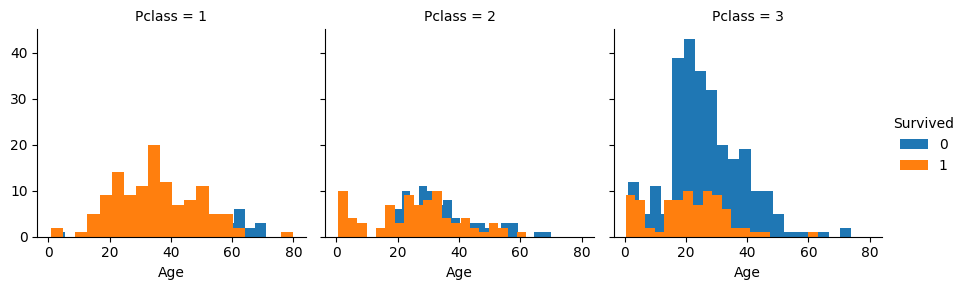

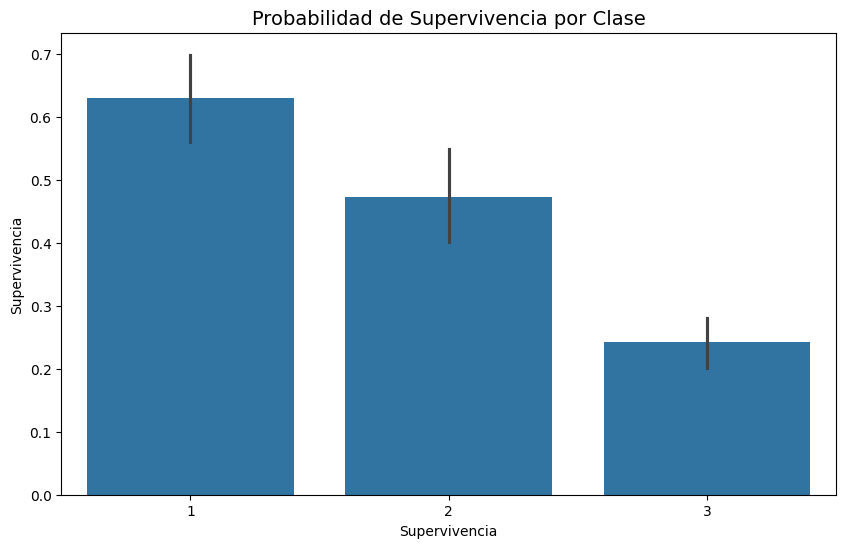

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [187]:
g = sns.FacetGrid(titanic, col='Pclass', hue='Survived')
g.map(plt.hist, 'Age', bins=20)
g.add_legend()

plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='Pclass', y='Survived')
plt.title('Probabilidad de Supervivencia por Clase', fontsize=14)
plt.ylabel('Supervivencia')
plt.xlabel('Supervivencia')
plt.show()

clase_supervivencia = titanic.groupby('Pclass')['Survived'].mean()
print((clase_supervivencia * 100).round(2))

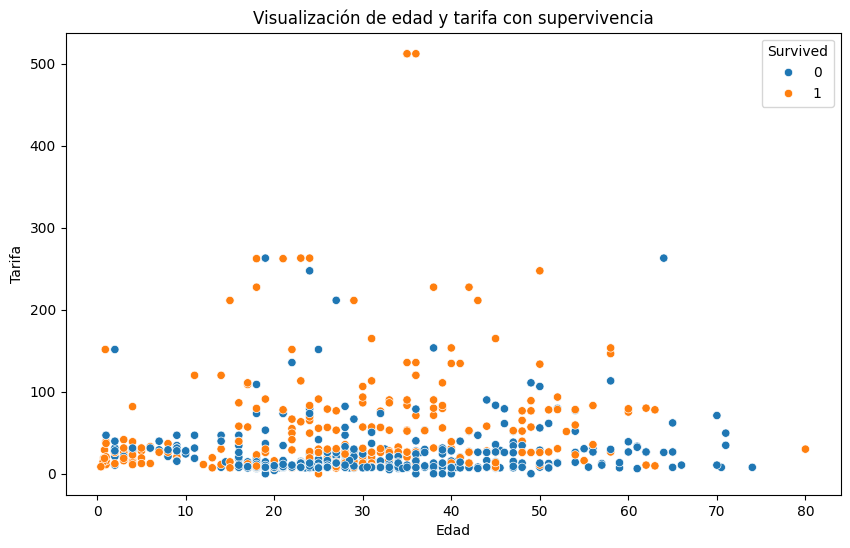

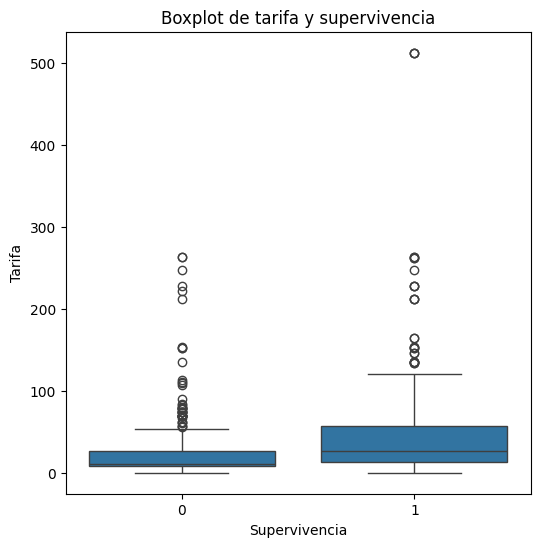

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic, x='Age', y='Fare', hue='Survived')
plt.ylabel('Tarifa')
plt.xlabel('Edad')
plt.title('Visualización de edad y tarifa con supervivencia')
plt.show()

plt.figure(figsize=(6, 6))
sns.boxplot(data=titanic, x='Survived', y='Fare')
plt.ylabel('Tarifa')
plt.xlabel('Supervivencia')
plt.title('Boxplot de tarifa y supervivencia')
plt.show()

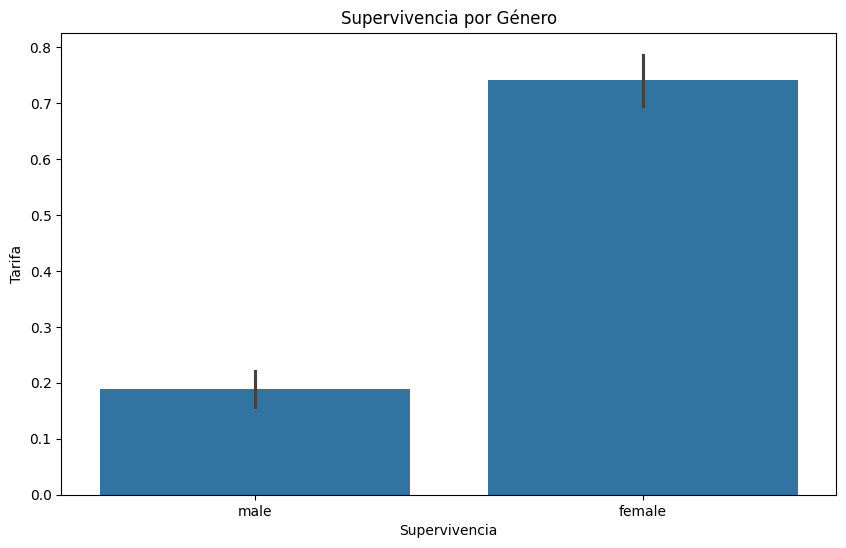

Porcentaje de hombres y mujeres
Sex
male      64.758698
female    35.241302
Name: count, dtype: float64
Supervivencia Porcentual
Survived      0      1
Sex                   
female     9.09  26.15
male      52.53  12.23


In [163]:
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='Sex', y='Survived')
plt.ylabel('Tarifa')
plt.xlabel('Supervivencia')
plt.title('Supervivencia por Género')
plt.show()

print("Porcentaje de hombres y mujeres")
print(sexo / len(titanic) * 100)

print("Supervivencia Porcentual")
sex_supervivencia = pd.crosstab(titanic['Sex'], titanic['Survived'])
print((sex_supervivencia / len(titanic) * 100).round(2))

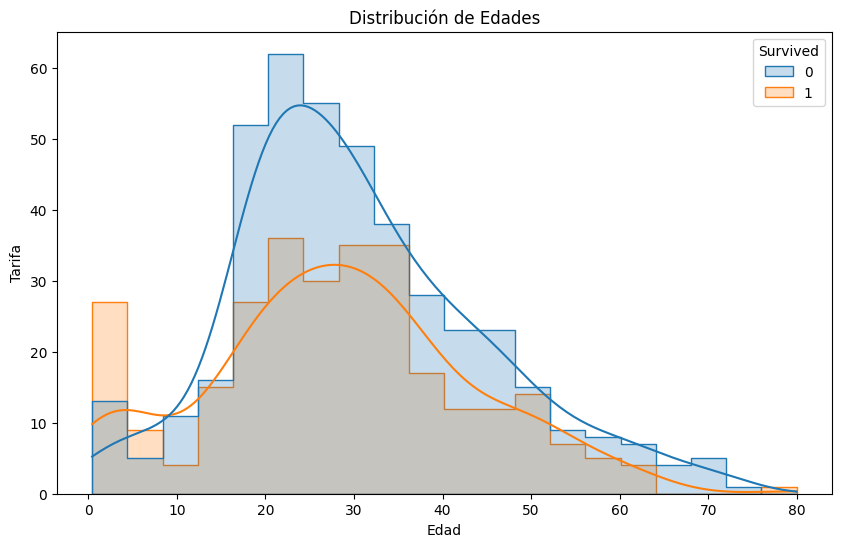

AgeStage
Niño           57.97
Adolescente    38.18
Juventud       36.52
Adulto         42.05
Anciano        22.73
Name: Survived, dtype: float64
Survived
0    77.27
1    22.73
Name: count, dtype: float64
Survived
1    53.98
0    46.02
Name: count, dtype: float64


In [175]:
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x='Age', hue='Survived', kde=True, element="step")
plt.title('Distribución de Edades')
plt.ylabel('Tarifa')
plt.xlabel('Edad')
plt.show()


titanic['AgeStage'] = pd.cut(titanic['Age'], bins=[0, 12, 20, 30, 60, 100], labels=['Niño', 'Adolescente', 'Juventud', 'Adulto', 'Anciano'])
supervivencia_edad = titanic.groupby('AgeStage')['Survived'].mean()
print((supervivencia_edad * 100).round(2))

print((mayores_60['Survived'].value_counts() / len(mayores_60) * 100).round(2))
print((menores_18['Survived'].value_counts() / len(menores_18) * 100).round(2))

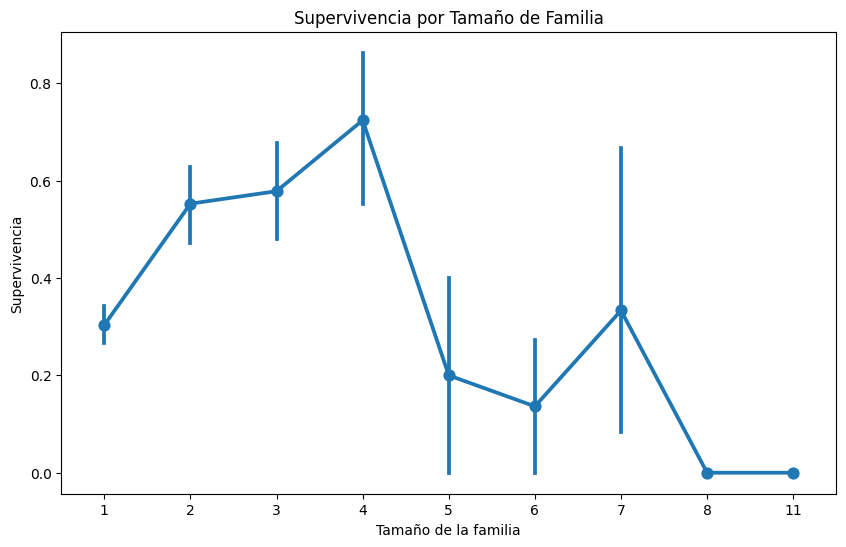

            Survived
FamilySize          
1              30.35
2              55.28
3              57.84
4              72.41
5              20.00
6              13.64
7              33.33
8               0.00
11              0.00


In [189]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=titanic, x='FamilySize', y='Survived')
plt.title('Supervivencia por Tamaño de Familia')
plt.ylabel('Supervivencia')
plt.xlabel('Tamaño de la familia')
plt.show()

familia_supervivencia = titanic.pivot_table(index='FamilySize', values='Survived') 
print((familia_supervivencia*100).round(2))

Explicacion de lo anterior y asi

## Parte 3: Valores Faltantes

In [62]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
msno.matrix(titanic)

## Parte 4: Una Pregunta Propia

Esta es la parte más importante. Formulen una pregunta original sobre el dataset que les parezca interesante y que no hayan visto en ejemplos de internet o tutoriales. Algunos criterios:

La pregunta debe requerir relacionar al menos 2 variables
Debe ser respondible con los datos disponibles
Debe requerir cierto razonamiento, no solo hacer una gráfica
Ejemplos de buenas preguntas:

"¿Los pasajeros que viajaban solos tuvieron diferente tasa de supervivencia que los que viajaban en familia?"
"¿Hubo un efecto de 'mujeres y niños primero' que variara según la clase social?"
No se vale: Hacer la misma pregunta que aparece en la documentación de Seaborn o en el primer tutorial de Google.